In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

In [3]:
tiny_loss=2.103500528335571
small_loss=1.8751439380645751
medium_loss=1.6547045993804932

In [5]:
tiny_params=112448
small_params=834432
medium_params=4821248

In [26]:
data_scale_10_loss=2.6093492794036863
data_scale_25_loss=2.364648847579956
data_scale_50_loss=2.138003306388855
data_scale_100_loss=1.8820109105110168

In [27]:
len_train=1003854

In [28]:
params = [tiny_params,small_params,medium_params]
val_los_params = [tiny_loss,small_loss,medium_loss]

In [29]:
tokens = [int(len_train*0.1),int(len_train*0.25),int(len_train*0.5),int(len_train*1)]
val_los_tokens=[data_scale_10_loss,data_scale_25_loss,data_scale_50_loss,data_scale_100_loss]

In [30]:
log_params = np.log(params)
log_val_los_params=np.log(val_los_params)

In [31]:
log_tokens = np.log(tokens)
log_val_los_tokens = np.log(val_los_tokens)

In [32]:
slopeN, interceptN = np.polyfit(log_params, log_val_los_params, 1)
alphaN = -slopeN

In [33]:
alphaN

np.float64(0.0636994534296971)

In [34]:
slopeD, interceptD = np.polyfit(log_tokens, log_val_los_tokens, 1)
alphad = -slopeD

In [35]:
alphad

np.float64(0.14102868006898037)

In [36]:
gamma = alphaN/alphad

In [37]:
gamma

np.float64(0.45167729995445066)

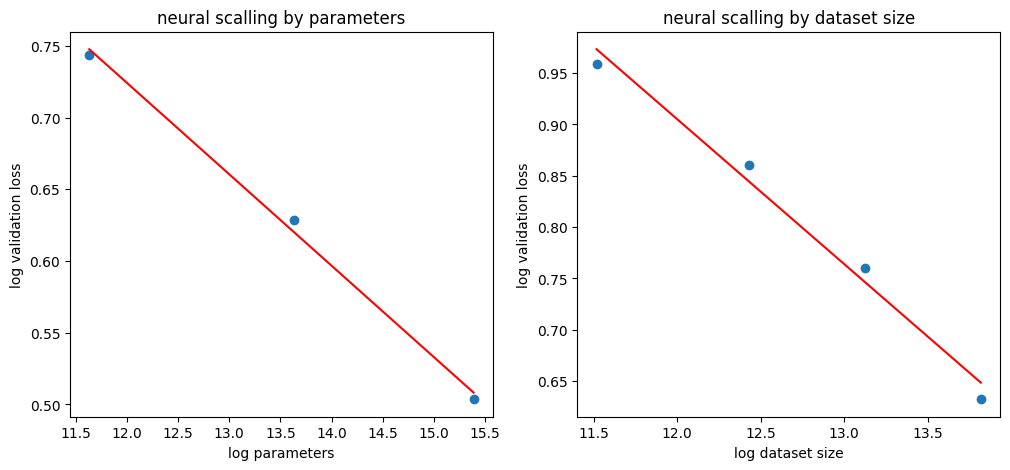

In [50]:
fig, (plot1,plot2)=plt.subplots(1,2, figsize=(12,5))

plot1.scatter(log_params,log_val_los_params)
plot1.plot(log_params,slopeN*log_params+interceptN, color='r')
plot1.set_title('neural scalling by parameters')
plot1.set_xlabel('log parameters')
plot1.set_ylabel('log validation loss')

plot2.scatter(log_tokens,log_val_los_tokens)
plot2.plot(log_tokens,slopeD*log_tokens+interceptD, color='r')
plot2.set_title('neural scalling by dataset size')
plot2.set_xlabel('log dataset size')
plot2.set_ylabel('log validation loss')
plt.savefig('scaling_laws.png')
plt.show()